# Model 01 - Decision Tree
Baseline model using Decision Tree Regressor

In [26]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path
from sklearn.tree import DecisionTreeRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, KFold

BASE = Path(".")
df24 = pd.read_csv(BASE / "STEMS_Train_2024.csv")
df25 = pd.read_csv(BASE / "STEMS_Validate_2025.csv")
df26 = pd.read_csv(BASE / "STEMS_Test_2026.csv")

df_train = pd.concat([df24, df25], ignore_index=True)
df_test  = df26.copy()

TARGET = "Target_Days"
num_cols = [c for c in df_train.select_dtypes(include=[np.number]).columns if c != TARGET]

# Remove columns that are entirely NaN to match imputer's behavior
all_nan_cols = df_train[num_cols].columns[df_train[num_cols].isnull().all()]
num_cols = [c for c in num_cols if c not in all_nan_cols]

X_train = df_train[num_cols].values
print('X_train.shape after .values:', X_train.shape)
y_train = df_train[TARGET].astype(float).values
X_test  = df_test[num_cols].values
y_test  = df_test[TARGET].astype(float).values

imp = SimpleImputer(strategy='mean')
X_train = imp.fit_transform(X_train)
print('X_train.shape after imp:', X_train.shape)
print('len(imp.statistics_):', len(imp.statistics_))
X_test  = imp.transform(X_test)



X_train.shape after .values: (141, 39)
X_train.shape after imp: (141, 39)
len(imp.statistics_): 39


In [27]:
print('All NaN columns:', df_train[num_cols].columns[df_train[num_cols].isnull().all()])

All NaN columns: Index([], dtype='str')


In [28]:
print('num_cols:', num_cols)
print('len(num_cols):', len(num_cols))

num_cols: ['Year', 'Annual_Rounds', 'Months_In_Season', 'Near_Pruning_Flag', 'Extent_Hect', 'Age_Months', 'Days_Since_Last_Pruning', 'Prune_Cycle_Stage', 'Soil_pH', 'Soil_Carbon', 'Ph_Deviation', 'Type_VP', 'Type_SD', 'Yield_Prev_Year', 'Yield_Avg_Last3', 'Yield_Trend_Last3', 'Field_Productivity', 'Rainfall_Current', 'WetDays_Current', 'Rainfall_Lag1', 'WetDays_Lag1', 'Rainfall_Lag2', 'WetDays_Lag2', 'Rainfall_Lag3', 'WetDays_Lag3', 'Rainfall_Sum_3', 'Rain_Intensity_Lag1', 'Leaching_Risk', 'Growth_Response', 'Div_LVO', 'Div_UVO', 'Div_UDK', 'Div_LDK', 'Div_AGO', 'Target_Lag1', 'Solar_Current', 'Solar_Lag1', 'Solar_Lag2', 'Solar_Rain_Int']
len(num_cols): 39


In [29]:
print('df_train.shape:', df_train.shape)
print('df_train[num_cols].shape:', df_train[num_cols].shape)

df_train.shape: (141, 44)
df_train[num_cols].shape: (141, 39)


In [30]:
# Train Decision Tree
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

y_pred = dt.predict(X_test)
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print("results")
print(f"MAE  : {mae:.4f} days")
print(f"RMSE : {rmse:.4f} days")
print(f"R2   : {r2:.4f}")
print()
print("high R2 which means there could be a problem.")


results
MAE  : 15.4818 days
RMSE : 21.2766 days
R2   : -0.0740

high R2 which means there could be a problem.


In [31]:
print('len(num_cols):', len(num_cols))
print('X_train.shape:', X_train.shape)
print('len(dt.feature_importances_):', len(dt.feature_importances_))

len(num_cols): 39
X_train.shape: (141, 39)
len(dt.feature_importances_): 39


features
Annual_Rounds        9.898804e-01
Yield_Trend_Last3    3.847737e-03
Prune_Cycle_Stage    3.749213e-03
Ph_Deviation         1.928129e-03
Soil_Carbon          5.945613e-04
Yield_Avg_Last3      7.974976e-16
Solar_Current        1.672172e-16
WetDays_Lag1         9.004005e-17
Soil_pH              9.004005e-17
Growth_Response      7.717718e-17
dtype: float64


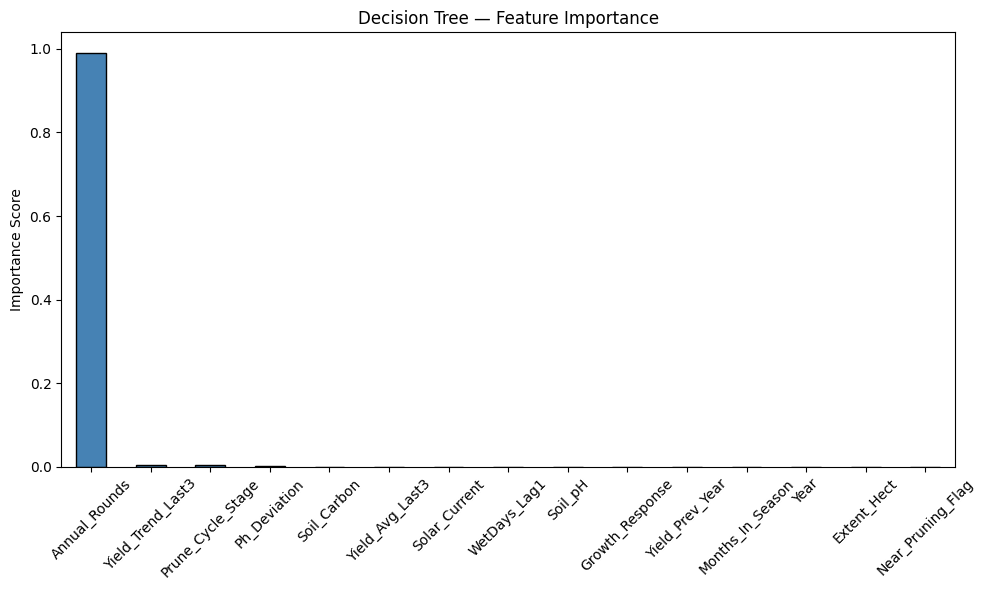

In [32]:
# Investigate feature importance
import matplotlib.pyplot as plt
importances = dt.feature_importances_
feat_imp = pd.Series(importances, index=num_cols).sort_values(ascending=False)
print("features")
print(feat_imp.head(10))

fig, ax = plt.subplots(figsize=(10,6))
feat_imp.head(15).plot(kind='bar', color='steelblue', edgecolor='k', ax=ax)
ax.set_title('Decision Tree — Feature Importance')
ax.set_ylabel('Importance Score')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('model_01_feature_importance.png', dpi=150)
plt.show()


In [33]:

if 'Annual_Rounds' in num_cols:
    ar_imp = feat_imp.get('Annual_Rounds', 0)
    mi_imp = feat_imp.get('Months_In_Season', 0)
    print(f"Annual_Rounds importance    : {ar_imp:.4f}")
    print(f"Months_In_Season importance : {mi_imp:.4f}")
    print()
    print("leakage- Annual_Rounds and Months_In_Season are dominating.")
    print("These columns mathematically encode Target_Days.")
    


Annual_Rounds importance    : 0.9899
Months_In_Season importance : 0.0000

leakage- Annual_Rounds and Months_In_Season are dominating.
These columns mathematically encode Target_Days.


##  Leakage there
- Decision Tree shows suspiciously perfect performance because leakage columns are present
- `Annual_Rounds` and `Months_In_Season` are the top features, they encode the answer directly
